In [1]:


get_ipython().run_line_magic('pip', 'install torch_geometric')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.3/193.3 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.5/219.5 kB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.3/243.3 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 26.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:


#version working upto 4 confusion matrix

# STEP 1: IMPORTS & DEVICE SETUP
import os
from datetime import datetime
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv,GATv2Conv
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import glob

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

import time
start_time = time.time()

# Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# === HYPERPARAMETERS ===
config = {
    "sequence_length": 40,              # How many time steps the model sees at once
    "future": 1,                        # How many steps into the future to predict
    "test_ratio": 0.25, # Train/test split

   #temporal settings
    "temporal_batch_size": 64,                   # For both train and test loaders
    "temporal_epochs": 25,                       # Number of training epochs
    "temporal_hidden_dim": 64,                   # Hidden representation size
    "temporal_num_heads": 4,                     # Attention heads
    "temporal_num_layers": 3,               # Transformer depth
    "temporal_dropout": 0.1,

    #spatial settings/GNN
    "spatial_batch_size": 64,
    "spatial_epochs": 50,
    "gnn_hidden": 8,                   # Hidden representation size
    "embedding_dim":64,
    "edge_feature_size": 9,
    "dropout": 0.1,
    "heads": 4,

    "num_rooms": 5                      # R1–R5
}

# Format: Year/Month/Day-Hour_Min_Sec (slashes replaced for folder safety)(added - and _ for better seperations)
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
RESULTS_DIR = os.path.join("results", f"Experiment_Results_{timestamp}")
os.makedirs(RESULTS_DIR, exist_ok=True)

summary_txt = os.path.join(RESULTS_DIR, "summary_metrics.txt")

# Save hyperparameters to summary file
with open(summary_txt, "w") as f:
    f.write(" HYPERPARAMETERS USED IN THIS RUN \n")
    for key, value in config.items():
        f.write(f"{key}: {value}\n")
    f.write("\n")

# Load specific room CSV files from a folder
DATA_DIR = "training_data"
csv_files = sorted(glob.glob(os.path.join(DATA_DIR,"*.csv")))
file_paths = {f"R{i+1}": csv_files[i] for i in range(min(5, len(csv_files)))}
room_list = list(file_paths.keys())
target_column = ['occupant_count [number]','room_num']
room_data = {}

for room, path in file_paths.items():
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.ffill().bfill()
    room_data[room] = df
# Tracking info
    print(f"{room} - Shape: {df.shape}")
    print(f"{room} - Columns: {df.columns.tolist()}")
    print(f"{room} - Null values per column:\n{df.isnull().sum()}")
    print(f"{room} - Unique occupant counts: {df[target_column].nunique()}")
    print(f"{room} - Sample data:\n{df.head()}")

"""SCALING OF DATA"""

# STEP 3: SCALING  Also add room_num to excluded columns
excluded_columns = ['timestamp', target_column[0], target_column[1]]
room_scaled_data = {}
scalers = {}



for room, df in room_data.items():
    print(f"\n Scaling data for {room} ")

    # Separate features and target
    features = df.drop(columns=excluded_columns)
    target = df[target_column]

    # Print feature shape and preview
    print(f"{room} - Features shape: {features.shape}")
    print(f"{room} - Feature columns: {features.columns.tolist()}")
    print(f"{room} - First 5 rows of features:\n{features.head()}")

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features)

    # Print scaled feature stats
    print(f"{room} - Scaled features shape: {scaled_features.shape}")
    print(f"{room} - First 3 rows of scaled features:\n{scaled_features[:3]}")

    # Store scaled data
    #scaler = StandardScaler()
    #scaled_features = scaler.fit_transform(features)
    room_scaled_data[room] = {
        'X': scaled_features,
        'y': target.values,
        'timestamp': df['timestamp'].values
    }
    scalers[room] = scaler

    # Target stats
    print(f"{room} - Target (y) shape: {target.shape}")
    print(f"{room} - Unique target values: {np.unique(target.values)}")

    # Timestamp range
    print(f"{room} - Timestamp range: {df['timestamp'].min()} to {df['timestamp'].max()}")

# STEP 4: SEQUENCE CREATION y will have to be a tuple of (occupant_count, room_num)
def create_sequences(X, y, timestamps, seq_len, future):
#Creates overlapping sequences of features and targets with a future
        #Args:
        #X: Feature matrix (scaled) everything except timestamp,target and room_num
        #y: Target values number of occupants and room number
        #timestamps: Corresponding timestamps
        #seq_len: Length of each input sequence
        #future: How many steps into the future to predict
        #Returns:
        #X_seq: Input sequences of shape [num_sequences, seq_len, num_features]
        #y_seq: Corresponding future targets
        #t_seq: Timestamps for each target

    X_seq, y_seq, t_seq = [], [], []
    for i in range(len(X) - seq_len - future + 1):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len + future - 1])
        t_seq.append(timestamps[i+seq_len + future - 1])
    return np.array(X_seq), np.array(y_seq), np.array(t_seq)

# Set parameters
sequence_length = config["sequence_length"]
future = config["future"]
test_ratio = config["test_ratio"]
room_sequences = {}

# Loop through each room and create sequences
for room in file_paths.keys():
    data = room_scaled_data[room]
    X_seq, y_seq, t_seq = create_sequences(data['X'], data['y'], data['timestamp'], sequence_length, future)
    # Print shapes to understand the structure
    print(f"{room} - Total sequences created: {X_seq.shape[0]}")
    print(f"{room} - Input sequence shape: {X_seq.shape} (should be [samples, seq_len, features])")
    print(f"{room} - Target shape: {y_seq.shape}")
    print(f"{room} - Timestamp shape: {t_seq.shape}")

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=test_ratio, shuffle=True)

    # Print split stats
    print(f"{room} - Training samples: {X_train.shape[0]}")
    print(f"{room} - Testing samples: {X_test.shape[0]}")

    # Store results
    room_sequences[room] = {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test
    }
#print("ytest",y_test)
#print("ytrain",y_train)
print(f"Data preprocessing complete. Results saved in: {RESULTS_DIR}")

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
R1 - Shape: (8352, 26)
R1 - Columns: ['air_temperature [Celsius]', 'baromatic_pressure [hPa]', 'ceiling_fan_energy [kWh]', 'chilled_water_energy [kWh]', 'dry_bulb_temp [Celsius]', 'global_horizontal_solar_radiation [W/m2]', 'illuminance [lux]', 'indoor_co2 [ppm]', 'indoor_relative_humidity [%]', 'lighting_energy [kWh]', 'occupant_count [number]', 'occupant_presence [binary]', 'outdoor_co2 [ppm]', 'outdoor_relative_humidity [%]', 'plug_load_energy [kWh]', 'pm2.5 [mu_g/m3]', 'sound_pressure_level [dba]', 'supply_air_pressure [Pa]', 'supply_air_temperature [Celsius]', 'temp_setpoint [Celsius]', 'timestamp', 'voc [ppb]', 'wifi_connected_devices [number]', 'wind_direction [Degree]', 'wind_speed [m/s]', 'room_num']
R1 - Null values per column:
air_temperature [Celsius]                   0
baromatic_pressure [hPa]                    0
ceiling_fan_energy [kWh]                    0
chilled_water_energy [kWh]                  0
dry_bulb_temp [Celsius]                     0
glo

In [3]:


direction_map = {
    
    "down": [1,0,0],
    "up":   [0,1,0],
    "same": [0,0,1]
}
path_map = {
    "corridor": [1,0],
    "staircase":[0,1]
}
#space function [0,0,0] first is lecture, middle is office, last is library
#Occupant type [0,0,0] first is Students, middle is admin staff, last is researchers
space_function = {
    "lecture": [1,0,0],
    "office": [0,1,0],
    "library": [0,0,1]
}
occupant_type = {
    "student": [1,0,0],
    "admin": [0,1,0],
    "researcher": [0,0,1]
}

In [4]:


#edge_information-dictionary
edge_features_dict = {

# ------------------ R1 connections ------------------
("R1","R2"): {
    "distance": 6.81,
    "stairs": 0,
    "level_difference": 0,
    "direction": direction_map["same"],
    "elevation_change": 4.02,
    "path_type": path_map["corridor"]
},

("R1","R3"): {
    "distance": 44.93,
    "stairs": 20,
    "level_difference": 1,
    "direction": direction_map["up"],
    "elevation_change": 8.10,
    "path_type": path_map["staircase"]
},

("R1","R4"): {
    "distance": 4.20,
    "stairs": 20,
    "level_difference": 1,
    "direction": direction_map["down"],
    "elevation_change": 8.00,
    "path_type": path_map["staircase"]
},

("R1","R5"): {
    "distance": 43.47,
    "stairs": 40,
    "level_difference": 2,
    "direction": direction_map["down"],
    "elevation_change": 9.17,
    "path_type": path_map["staircase"]
},

# ------------------ R2 connections ------------------
("R2","R3"): {
    "distance": 46.37,
    "stairs": 20,
    "level_difference": 1,
    "direction": direction_map["up"],
    "elevation_change": 8.10,
    "path_type": path_map["staircase"]
},

("R2","R4"): {
    "distance": 5.15,
    "stairs": 40,
    "level_difference": 1,
    "direction": direction_map["down"],
    "elevation_change": 8.00,
    "path_type": path_map["staircase"]
},

("R2","R5"): {
    "distance": 43.68,
    "stairs": 40,
    "level_difference": 2,
    "direction": direction_map["down"],
    "elevation_change": 9.17,
    "path_type": path_map["staircase"]
},

# ------------------ R3 connections ------------------
("R3","R4"): {
    "distance": 46.75,
    "stairs": 40,
    "level_difference": 2,
    "direction": direction_map["down"],
    "elevation_change": 8.10,
    "path_type": path_map["staircase"]
},

("R3","R5"): {
    "distance": 15.12,
    "stairs": 60,
    "level_difference": 3,
    "direction": direction_map["down"],
    "elevation_change": 9.27,
    "path_type": path_map["staircase"]
},

# ------------------ R4 connections ------------------
("R4","R5"): {
    "distance": 42.89,
    "stairs": 10,
    "level_difference": 1,
    "direction": direction_map["down"],
    "elevation_change": 9.17,
    "path_type": path_map["staircase"]
}
}
#node_information-List
#space function [0,0,0] first is lecture, middle is office, last is library
#Occupant type [0,0,0] first is Students, middle is admin staff, last is researchers
#SpaceFunction,OccupantType,Level,FloorArea,Floor_to_Ceiling,RoomVolume,SeatingCapacity,MaxOccupDensity,

node_feature = torch.tensor([
[
    *space_function["lecture"], *occupant_type["student"]
 ,4,118.6,4.1,486.2,40,3.0
],
    
[
    *space_function["lecture"],  *occupant_type["student"] 
    ,4,53.7,4.1,220.2,40,1.3
],

[
    *space_function["office"], *occupant_type["admin"] ,
 5,98.4,4.2,413.2,15,6.6
],

[
    *space_function["office"], *occupant_type["researcher"]  ,
    3,141.9,4.1,581.7,25,5.6
],

[
    *space_function["library"],  *occupant_type["student"]  ,
    2,182.8,7.5,1363.3,36,5.0
]
], dtype=torch.float)

In [5]:


NODE_ONEHOT_COLS = list(range(6))
NODE_CONT_COLS = list(range(6,12))

node_np = node_feature.numpy()

node_scalar = StandardScaler()

node_scaled = node_np.copy()

node_scaled[:, NODE_CONT_COLS] = node_scalar.fit_transform(node_np[:,NODE_CONT_COLS])

node_features_scaled = torch.tensor(node_scaled, dtype = torch.float)
print(node_features_scaled)

tensor([[ 1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.3922, -0.0111,
         -0.5183, -0.3220,  0.8993, -0.6821],
        [ 1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,  0.3922, -1.5173,
         -0.5183, -0.9980,  0.8993, -1.5742],
        [ 0.0000,  1.0000,  0.0000,  0.0000,  1.0000,  0.0000,  1.3728, -0.4799,
         -0.4443, -0.5075, -1.6555,  1.2069],
        [ 0.0000,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000, -0.5883,  0.5296,
         -0.5183, -0.0793, -0.6336,  0.6821],
        [ 0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000, -1.5689,  1.4788,
          1.9992,  1.9069,  0.4905,  0.3673]])


In [6]:


def edge_dict_to_tensor(edge_features_dict):
    rows = []
    edge_index_list = []
    #Think about loop to automatically index the rooms
    room_to_id = {
        f"R{i+1}":i for i in range(config["num_rooms"])
    }
    for (src,dst), feat in edge_features_dict.items():
        row = [
            feat["distance"],
            feat["stairs"],
            feat["level_difference"],
            *feat["direction"],
            feat["elevation_change"],
            *feat["path_type"]
            ]
        rows.append(row)
        edge_index_list.append([room_to_id[src],room_to_id[dst]])
    return torch.tensor(rows, dtype = torch.float),torch.tensor(edge_index_list).T

edge_attr, edge_index = edge_dict_to_tensor(edge_features_dict)
#0 for distance, 1:stairs, 2:level_difference, 6:elevation change
EDGE_CONT_COLS = [0,1,2,6]
#3,4,5:directions and 7,8: path_types
EDGE_ONEHOT_COLS = [3,4,5,7,8]

edge_np = edge_attr.numpy()
edge_scalar = StandardScaler()
edge_scaled = edge_np.copy()
edge_scaled[:,EDGE_CONT_COLS] = edge_scalar.fit_transform(edge_np[:,EDGE_CONT_COLS])

edge_attr_scaled = torch.tensor(edge_scaled, dtype=torch.float)
 


In [7]:


def symmetric(key, edge):
    sym_edge = edge.copy()
    if edge["direction"]==direction_map["down"]:
        sym_edge["direction"]=direction_map["up"]
    elif edge["direction"] ==direction_map["up"]:
        sym_edge["direction"]=direction_map["down"]
    sym_key = (key[1],key[0])
    return sym_key, sym_edge
    


In [8]:


#Switch the room order

In [9]:


#step 4:
import torch
import torch.nn as nn
#Make the model be modular
#  Temporal Transformer Encoder for One Room
class TemporalTransformerEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_heads, num_layers, dropout):
      #input_dim: number of features per time step
      #hidden_dim: size the Transformer will use internally
      #num_heads: how many attention heads for better learning
      #num_layers: how many Transformer layers to stack

        super().__init__() #super().__init__() calls the parent class nn.Module to initialize everything
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        # This is a linear layer that changes the input size.
        #For example: if each time step has 23 features (input_dim=23), and you want to use hidden_dim=64,
        #this layer changes the shape from (batch, seq_len, 23) → (batch, seq_len, 64).

        #This sets up one Transformer block:
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, #the size of each hidden vector
            nhead=num_heads,#number of attention heads
            dim_feedforward=hidden_dim * 2,#the internal layer size inside the transformer
            dropout=dropout,#randomly turn off 10% of the neurons during training to avoid overfitting
            batch_first=True
        )

        #This stacks multiple encoder layers together (like putting num_layers blocks on top of each other
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    #This is the function that runs when you pass data into the encoder
    def forward(self, x):  # x: (batch, seq_len, input_dim)
        x = self.input_proj(x)  # change input size to match hidden_dim
        x = self.encoder(x)     # apply transformer encoder
        return x

In [10]:


#Switch to GNN
# Spatial- Model for Multiple Rooms
class MultiRoomGNNModel(nn.Module):
    def __init__(self, transformer, embedding_dim, node_feature_dim, edge_feature_dim, gnn_hidden, num_rooms,heads, dropout):
        super().__init__()
        self.transformer = transformer
        self.num_rooms = num_rooms
        
        # Retain the temporal head projection to keep your downstream loop compatible
        self.temp_occ_head = nn.Linear(embedding_dim, 1)
        
        # Sequential edge MLP setup (fixed commas and parenthesis)
        combined_dim = embedding_dim + node_feature_dim
        '''self.edge_mlp = nn.Sequential(
            nn.Linear(edge_feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, combined_dim * gnn_hidden)
        )
        '''
        self.gnn1 = GATConv(
            combined_dim,
            gnn_hidden,
            heads,
            dropout,
            edge_feature_dim
        )
        
        self.dropout = nn.Dropout(dropout)
        self.occ_head = nn.Linear(gnn_hidden*heads, 1)
        self.room_head = nn.Linear(gnn_hidden*heads, num_rooms)

    def forward(self, room_sequences, edge_index, edge_attr, node_features):  
        '''
        room_sequences: (batch_size, num_rooms, seq_len, num_features)
        edge_index:     (2, num_edges)
        edge_attr:      (num_edges, edge_feature_dim)
        node_features:  (num_rooms, node_feature_dim)
        '''
        B, num_rooms, seq_len, num_features = room_sequences.shape
        
        # 1. Flatten Batch and Room dimensions for the Temporal Transformer
        x_flat = room_sequences.view(B * num_rooms, seq_len, num_features)
        transformer_out = self.transformer(x_flat)  # Shape: (B * num_rooms, seq_len, embedding_dim)
        
        # 2. Collapse the time dimension by pulling the last timestep
        x_nodes = transformer_out[:, -1, :]  # Shape: (B * num_rooms, embedding_dim)
        
        # 3. Generate Temporal Predictions 
        temporal_predictions = self.temp_occ_head(x_nodes).view(B, num_rooms)
        
        # 4. Concatenate static node features (replicated across the batch)
        node_features_expanded = node_features.repeat(B, 1)  # Shape: (B * num_rooms, node_feature_dim)
        x_combined = torch.cat([x_nodes, node_features_expanded], dim=-1)  # Shape: (B * num_rooms, combined_dim)
        
        # 5. Dynamically construct batched disjoint graphs for PyG
        edge_shifts = torch.arange(B, device=edge_index.device).view(B, 1, 1) * num_rooms
        batched_edge_index = (edge_index.unsqueeze(0) + edge_shifts).transpose(0, 1).reshape(2, -1)
        batched_edge_attr = edge_attr.repeat(B, 1)
        
        # 6. Pass through the GNN
        x_gnn = self.gnn1(x_combined, batched_edge_index, edge_attr=batched_edge_attr)
        x_gnn = F.elu(x_gnn)
        x_gnn = self.dropout(x_gnn)
        
        # 7. Project Spatial predictions and shape them to match your original loops
        spatial_occupancy_predictions = self.occ_head(x_gnn).view(B, num_rooms)
        spatial_room_predictions = self.room_head(x_gnn).view(B, num_rooms, num_rooms)
        #Return temporal_predictions
        return spatial_occupancy_predictions, spatial_room_predictions

In [11]:


import numpy as np
import torch
from torch.utils.data import Dataset

class MultiRoomDataset(Dataset):
    def __init__(self, room_sequences, room_names, is_train=True, shuffle_rooms=True):
        self.room_names = room_names

        data_key_X = 'X_train' if is_train else 'X_test'
        data_key_y = 'y_train' if is_train else 'y_test'

        #num_samples = len(room_sequences[self.room_names[0]][data_key_X])
        num_samples = min(len(room_sequences[room][data_key_X]) for room in self.room_names)

        num_rooms = len(self.room_names)

        X_list = []
        y_list = []

        # Build dataset (no shuffling yet)
        for i in range(num_samples):
            rooms_input = []
            rooms_target = []

            for room in self.room_names:
                rooms_input.append(room_sequences[room][data_key_X][i])
                rooms_target.append(room_sequences[room][data_key_y][i])

            X_list.append(np.stack(rooms_input))   # (num_rooms, seq_len, features)
            y_list.append(np.array(rooms_target)) # (num_rooms,)

        # Convert to numpy arrays
        np_X = np.array(X_list)
        np_y = np.array(y_list)

        # Handle NaNs/Infs
        np_X = np.nan_to_num(np_X, nan=0.0,
                            posinf=np.finfo(np.float32).max,
                            neginf=np.finfo(np.float32).min)

        np_y = np.nan_to_num(np_y, nan=0.0,
                            posinf=np.finfo(np.float32).max,
                            neginf=np.finfo(np.float32).min)

        if shuffle_rooms:
          num_samples, num_rooms, seq_len, num_features = np_X.shape

          perms = np.array([np.random.permutation(num_rooms) for _ in range(num_samples)])

          # Shuffle X
          np_X = np.stack([
              np_X[i, perms[i], :, :]
              for i in range(num_samples)
          ])

          # Shuffle y
          np_y = np.stack([
              np_y[i, perms[i]]
              for i in range(num_samples)
          ])


        # Convert to tensors
        self.X = torch.tensor(np_X, dtype=torch.float32)
        self.y = torch.tensor(np_y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

from torch.utils.data import TensorDataset

train_dataset = MultiRoomDataset(room_sequences,room_list, is_train=True,shuffle_rooms=True)
train_loader = DataLoader(train_dataset, batch_size=config["spatial_batch_size"], shuffle=True)
for i, (x, y) in enumerate(train_loader):
    print("Batch:", i)
    print("Input shape:", x.shape)
    print("Output shape:", y.shape)
    print("Labels:", y)

    break  # stop after first batch



test_dataset = MultiRoomDataset(room_sequences, room_list, is_train=False)
test_loader = DataLoader(test_dataset, batch_size=config["spatial_batch_size"], shuffle=False)# shuffle=False for consistent evaluation
# MODEL HYPERPARAMETERS
num_sensor_features = room_scaled_data['R1']['X'].shape[1]   # Total number of features per timestep it is ok to have only room1 because all rooms R1–R5 have the same number of sensor features

# We do NOT need to instantiate TemporalTransformerEncoder separately.
# The MultiRoomTransformerModel automatically creates one TemporalTransformerEncoder
# for each room inside its __init__ method using a loop:
#     self.room_encoders = nn.ModuleList([...])
# This means each room gets its own dedicated temporal encoder.
# These encoders are then used inside the model's forward pass, so we only need to
# instantiate the full multi_room_model once, and it already includes:
#   - Temporal encoders for each room
#   - A shared spatial encoder to combine room information
#   - Output prediction heads for temporal and spatial predictions

#INSTANTIATE MULTI-ROOM TRANSFORMER MODEL
# 1. Setup the temporal component
temporal_encoder = TemporalTransformerEncoder(
    input_dim=num_sensor_features,
    hidden_dim=config["temporal_hidden_dim"],
    num_heads=config["temporal_num_heads"],
    num_layers=config["temporal_num_layers"],
    dropout=config["temporal_dropout"]
)

# 2. Setup the full GNN wrapper
multi_room_model = MultiRoomGNNModel(
    transformer=temporal_encoder,
    embedding_dim=config["embedding_dim"],
    node_feature_dim=node_features_scaled.shape[1],
    edge_feature_dim=config["edge_feature_size"],
    gnn_hidden=config["gnn_hidden"],
    num_rooms=config["num_rooms"],
    heads=config["heads"],
    dropout=config["dropout"]
).to(device)

Batch: 0
Input shape: torch.Size([64, 5, 40, 23])
Output shape: torch.Size([64, 5, 2])
Labels: tensor([[[ 2.,  5.],
         [ 0.,  4.],
         [ 2.,  3.],
         [ 0.,  2.],
         [ 3.,  1.]],

        [[ 0.,  4.],
         [ 0.,  2.],
         [ 0.,  1.],
         [ 0.,  5.],
         [ 1.,  3.]],

        [[ 0.,  1.],
         [ 2.,  3.],
         [ 0.,  4.],
         [ 1.,  2.],
         [ 0.,  5.]],

        [[ 0.,  1.],
         [ 0.,  2.],
         [ 0.,  4.],
         [ 1.,  3.],
         [ 0.,  5.]],

        [[ 3.,  2.],
         [ 0.,  4.],
         [ 0.,  5.],
         [ 0.,  1.],
         [ 0.,  3.]],

        [[ 0.,  2.],
         [ 0.,  3.],
         [ 4.,  4.],
         [ 0.,  5.],
         [ 0.,  1.]],

        [[ 1.,  1.],
         [ 0.,  3.],
         [ 0.,  5.],
         [ 0.,  2.],
         [ 5.,  4.]],

        [[ 0.,  2.],
         [ 0.,  5.],
         [ 0.,  1.],
         [ 3.,  3.],
         [ 0.,  4.]],

        [[ 0.,  2.],
         [ 0.,  5.],
       

In [12]:


room_names = list(file_paths.keys())
spatial_train_losses_per_room = {room: [] for room in room_names}
spatial_test_losses_per_room = {room: [] for room in room_names}
spatial_train_accs_per_room = {room: [] for room in room_names}
spatial_test_accs_per_room = {room: [] for room in room_names}
spatial_preds_per_room = {}
spatial_actuals_per_room = {}
spatial_occupancy_preds_per_room = {room: [] for room in room_names}
spatial_room_preds_per_room = {room: [] for room in room_names}
spatial_occupancy_actuals_per_room = {room: [] for room in room_names}
spatial_rooms_actuals_per_room = {room: [] for room in room_names}

In [13]:


def train_multiroom_model(model, train_loader, test_loader, epochs, lr, edge_index, edge_attr, node_features):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    # Loss objectives matching your multi-task targets
    criterion = nn.MSELoss()                  # Occupancy regression
    classification = nn.CrossEntropyLoss()     # Room localization
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    w1, w2 = 1.0, 1.0
    print(f"Starting GNN training for {epochs} epochs...")
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            
            # Unpack the two tasks your GNN architecture maps out
            spatial_occupancy_pred, spatial_roomnum_pred = model(
                X_batch, 
                edge_index.to(device), 
                edge_attr.to(device), 
                node_features.to(device)
            )
            
            # Multi-task objective computations
            loss_occ = criterion(spatial_occupancy_pred, y_batch[..., 0])
            loss_room = classification(
                spatial_roomnum_pred.view(-1, config["num_rooms"]),
                (y_batch[..., 1] - 1).long().view(-1)
            )
            
            loss = w1 * loss_occ + w2 * loss_room
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        #if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Combined Loss: {total_loss/len(train_loader):.4f}")
            
    # Evaluation Track
    model.eval()
    preds_occup, preds_room = [], []
    actuals_occup, actuals_room = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            
            spatial_occupancy_pred, spatial_roomnum_pred = model(
                X_batch, 
                edge_index.to(device), 
                edge_attr.to(device), 
                node_features.to(device)
            )
            
            preds_occup.append(spatial_occupancy_pred.cpu().numpy())
            preds_room.append(spatial_roomnum_pred.cpu().numpy())
            actuals_occup.append(y_batch[..., 0].numpy())
            actuals_room.append(y_batch[..., 1].numpy())
            
    return (np.concatenate(preds_occup, axis=0), 
            np.concatenate(preds_room, axis=0), 
            np.concatenate(actuals_occup, axis=0), 
            np.concatenate(actuals_room, axis=0))

In [23]:

import subprocess
import sys
subprocess.check_call([sys.executable, "-m" , "pip", "install", "optuna"])
subprocess.check_call([sys.executable, "-m" , "pip", "install", "ipympl"])
import optuna
import time
import psutil
import os
import torch

[I 2026-06-16 14:25:48,812] A new study created in memory with name: no-name-e70ddfb3-f848-4d1a-8eb2-032e215637e3
[I 2026-06-16 14:26:14,617] Trial 0 finished with value: 0.8568553752971418 and parameters: {'epochs': 53}. Best is trial 0 with value: 0.8568553752971418.
[I 2026-06-16 14:26:25,834] Trial 1 finished with value: 0.8740420332460692 and parameters: {'epochs': 23}. Best is trial 0 with value: 0.8568553752971418.
[I 2026-06-16 14:26:30,219] Trial 2 finished with value: 0.9812253198840402 and parameters: {'epochs': 9}. Best is trial 0 with value: 0.8568553752971418.
[I 2026-06-16 14:27:19,123] Trial 3 finished with value: 0.8693553859537299 and parameters: {'epochs': 100}. Best is trial 0 with value: 0.8568553752971418.
[I 2026-06-16 14:28:00,293] Trial 4 finished with value: 0.9187444358161001 and parameters: {'epochs': 84}. Best is trial 0 with value: 0.8568553752971418.
[I 2026-06-16 14:28:25,313] Trial 5 finished with value: 0.8767793792666811 and parameters: {'epochs': 51}

Best Epochs: 91
Best Validation Loss: 0.8199894699183378


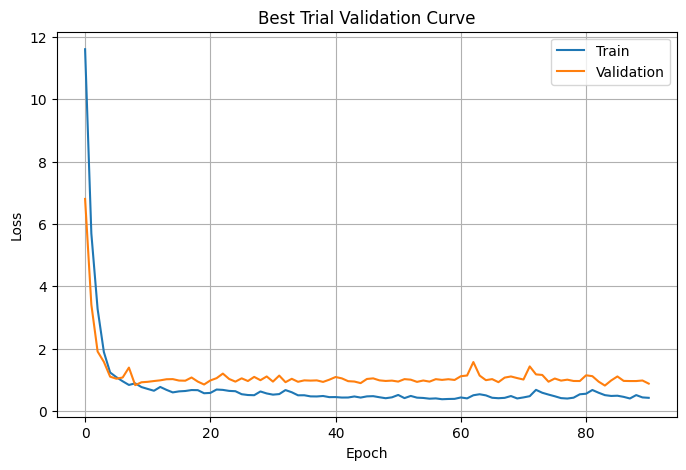

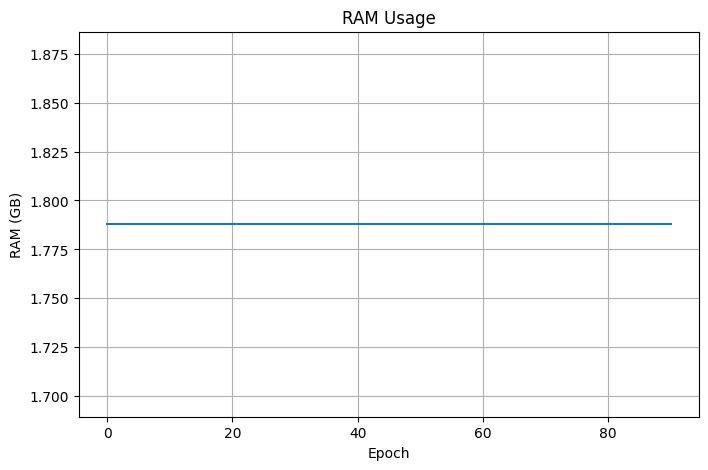

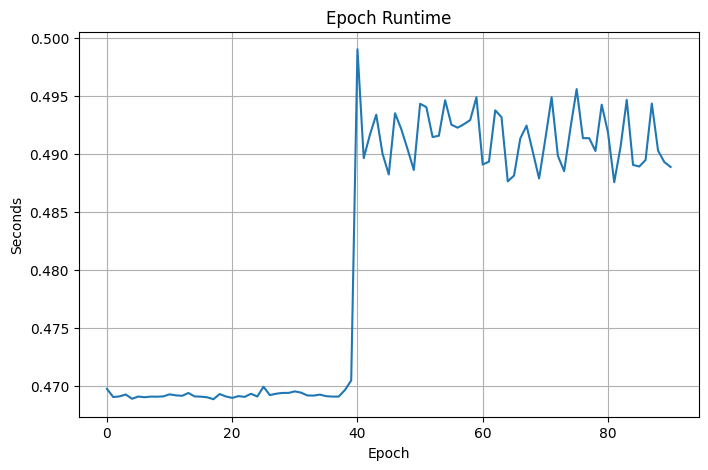

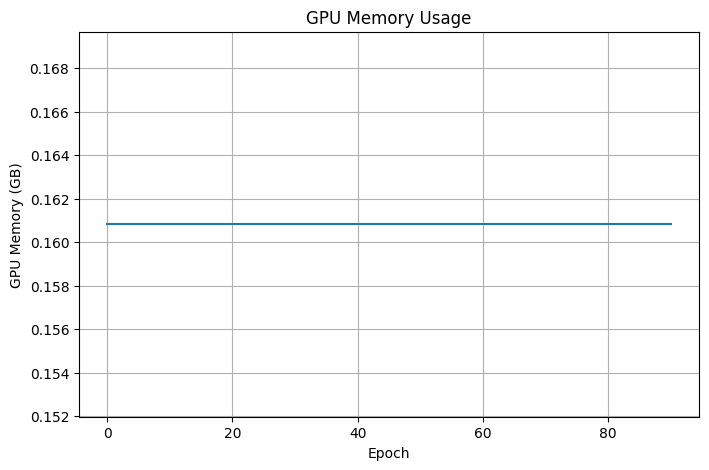

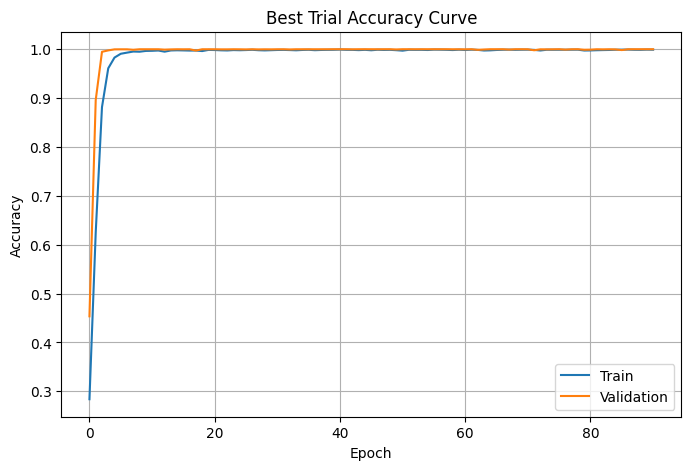

Starting GNN training for 91 epochs...
Epoch [1/91] - Combined Loss: 10.9580
Epoch [2/91] - Combined Loss: 5.2374
Epoch [3/91] - Combined Loss: 2.9625
Epoch [4/91] - Combined Loss: 1.8693
Epoch [5/91] - Combined Loss: 1.3228
Epoch [6/91] - Combined Loss: 1.3013
Epoch [7/91] - Combined Loss: 0.9682
Epoch [8/91] - Combined Loss: 0.8944
Epoch [9/91] - Combined Loss: 0.9787
Epoch [10/91] - Combined Loss: 1.0028
Epoch [11/91] - Combined Loss: 0.7370
Epoch [12/91] - Combined Loss: 0.7108
Epoch [13/91] - Combined Loss: 0.7380
Epoch [14/91] - Combined Loss: 0.6758
Epoch [15/91] - Combined Loss: 0.6603
Epoch [16/91] - Combined Loss: 0.6583
Epoch [17/91] - Combined Loss: 0.6305
Epoch [18/91] - Combined Loss: 0.6815
Epoch [19/91] - Combined Loss: 0.7198
Epoch [20/91] - Combined Loss: 0.7575
Epoch [21/91] - Combined Loss: 0.5769
Epoch [22/91] - Combined Loss: 0.5512
Epoch [23/91] - Combined Loss: 0.5081
Epoch [24/91] - Combined Loss: 0.5425
Epoch [25/91] - Combined Loss: 0.5222
Epoch [26/91] - Com

In [24]:
import optuna
from copy import deepcopy

def objective(trial):

    epochs = trial.suggest_int("epochs", 5, 100)

    model = MultiRoomGNNModel(
        transformer=temporal_encoder,
        embedding_dim=config["embedding_dim"],
        node_feature_dim=node_features_scaled.shape[1],
        edge_feature_dim=edge_attr.shape[1],
        gnn_hidden=config["gnn_hidden"],
        num_rooms=config["num_rooms"],
        heads=config["heads"],
        dropout=config["dropout"]
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion_occ = nn.MSELoss()
    criterion_room = nn.CrossEntropyLoss()

    train_loss_curve = []
    val_loss_curve = []

    train_acc_curve = []
    val_acc_curve = []

    epoch_time_curve = []
    ram_curve = []
    gpu_curve = []
    best_val = float("inf")

    for epoch in range(epochs):
        epoch_start = time.time()
        # ---------------- TRAIN ----------------
        model.train()

        train_loss = 0
        correct = 0
        total = 0

        for room_seq, y_batch in train_loader:

            room_seq = room_seq.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            preds_occ, preds_room = model(
                room_seq,
                edge_index,
                edge_attr,
                node_features_scaled
            )

            loss_occ = criterion_occ(
                preds_occ,
                y_batch[...,0]
            )

            loss_room = criterion_room(
                preds_room.view(-1, config["num_rooms"]),
                (y_batch[...,1]-1).long().view(-1)
            )

            loss = loss_occ + 2.0 * loss_room

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred_labels = preds_room.argmax(dim=-1)
            actual_labels = (y_batch[...,1]-1).long()

            correct += (pred_labels == actual_labels).sum().item()
            total += actual_labels.numel()

        train_loss /= len(train_loader)
        train_acc = correct / total
        
        # ---------------- VALIDATION ----------------
        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for room_seq, y_batch in test_loader:

                room_seq = room_seq.to(device)
                y_batch = y_batch.to(device)

                preds_occ, preds_room = model(
                    room_seq,
                    edge_index,
                    edge_attr,
                    node_features_scaled
                )

                loss_occ = criterion_occ(
                    preds_occ,
                    y_batch[...,0]
                )

                loss_room = criterion_room(
                    preds_room.view(-1, config["num_rooms"]),
                    (y_batch[...,1]-1).long().view(-1)
                )

                loss = loss_occ + 2.0 * loss_room

                val_loss += loss.item()

                pred_labels = preds_room.argmax(dim=-1)
                actual_labels = (y_batch[...,1]-1).long()

                correct += (pred_labels == actual_labels).sum().item()
                total += actual_labels.numel()

        val_loss /= len(test_loader)
        val_acc = correct / total

        train_loss_curve.append(train_loss)
        val_loss_curve.append(val_loss)

        train_acc_curve.append(train_acc)
        val_acc_curve.append(val_acc)

        trial.report(val_loss, epoch)
        epoch_time = time.time() - epoch_start

        process = psutil.Process(os.getpid())
        ram_gb = process.memory_info().rss / (1024**3)

        if torch.cuda.is_available():
            gpu_gb = torch.cuda.max_memory_allocated() / (1024**3)
        else:
            gpu_gb = 0

        epoch_time_curve.append(epoch_time)
        ram_curve.append(ram_gb)
        gpu_curve.append(gpu_gb)

        torch.cuda.reset_peak_memory_stats()
        if trial.should_prune():
            raise optuna.TrialPruned()

        best_val = min(best_val, val_loss)

    trial.set_user_attr("train_loss_curve", train_loss_curve)
    trial.set_user_attr("val_loss_curve", val_loss_curve)

    trial.set_user_attr("train_acc_curve", train_acc_curve)
    trial.set_user_attr("val_acc_curve", val_acc_curve)
    trial.set_user_attr("epoch_time_curve", epoch_time_curve)
    trial.set_user_attr("ram_curve", ram_curve)
    trial.set_user_attr("gpu_curve", gpu_curve)
    return best_val
edge_index = edge_index.to(device)
edge_attr = edge_attr.to(device)
node_features_scaled = node_features_scaled.to(device)
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(
    objective,
    n_trials=100,
    timeout=7200
)

best_epochs = study.best_trial.params["epochs"]

print("Best Epochs:", best_epochs)
print("Best Validation Loss:", study.best_trial.value)

best = study.best_trial

plt.figure(figsize=(8,5))
plt.plot(best.user_attrs["train_loss_curve"], label="Train")
plt.plot(best.user_attrs["val_loss_curve"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best Trial Validation Curve")
plt.legend()
plt.grid()
plt.show()
#RAM
plt.figure(figsize=(8,5))
plt.plot(best.user_attrs["ram_curve"])
plt.xlabel("Epoch")
plt.ylabel("RAM (GB)")
plt.title("RAM Usage")
plt.grid(True)
plt.show()
#TIME
plt.figure(figsize=(8,5))
plt.plot(best.user_attrs["epoch_time_curve"])
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.title("Epoch Runtime")
plt.grid(True)
plt.show()
#GPU
plt.figure(figsize=(8,5))
plt.plot(best.user_attrs["gpu_curve"])
plt.xlabel("Epoch")
plt.ylabel("GPU Memory (GB)")
plt.title("GPU Memory Usage")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(best.user_attrs["train_acc_curve"], label="Train")
plt.plot(best.user_attrs["val_acc_curve"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Best Trial Accuracy Curve")
plt.legend()
plt.grid()
plt.show()

final_epochs = study.best_trial.params["epochs"]


final_model= MultiRoomGNNModel(
    transformer=temporal_encoder,
    embedding_dim=config["embedding_dim"],
    node_feature_dim=node_features_scaled.shape[1],
    edge_feature_dim=edge_attr.shape[1],
    gnn_hidden=config["gnn_hidden"],
    num_rooms=config["num_rooms"],
    heads=config["heads"],
    dropout=config["dropout"]
).to(device)

preds_occ_np, preds_room_np, actual_occ_np, actual_room_np = (
    train_multiroom_model(
        model=final_model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=final_epochs,
        lr=0.001,
        edge_index=edge_index,
        edge_attr=edge_attr,
        node_features=node_features_scaled
    )
)


Starting GNN training for 59 epochs...
Epoch [1/59] - Combined Loss: 0.4697
Epoch [2/59] - Combined Loss: 0.4876
Epoch [3/59] - Combined Loss: 0.4797
Epoch [4/59] - Combined Loss: 0.4849
Epoch [5/59] - Combined Loss: 0.4938
Epoch [6/59] - Combined Loss: 0.4676
Epoch [7/59] - Combined Loss: 0.4420
Epoch [8/59] - Combined Loss: 0.4816
Epoch [9/59] - Combined Loss: 0.5400
Epoch [10/59] - Combined Loss: 0.5403
Epoch [11/59] - Combined Loss: 0.4402
Epoch [12/59] - Combined Loss: 0.4877
Epoch [13/59] - Combined Loss: 0.4679
Epoch [14/59] - Combined Loss: 0.4697
Epoch [15/59] - Combined Loss: 0.4780
Epoch [16/59] - Combined Loss: 0.4475
Epoch [17/59] - Combined Loss: 0.3951
Epoch [18/59] - Combined Loss: 0.4730
Epoch [19/59] - Combined Loss: 0.4737
Epoch [20/59] - Combined Loss: 0.5394
Epoch [21/59] - Combined Loss: 0.6683
Epoch [22/59] - Combined Loss: 0.4981
Epoch [23/59] - Combined Loss: 0.5294
Epoch [24/59] - Combined Loss: 0.6420
Epoch [25/59] - Combined Loss: 0.5220
Epoch [26/59] - Comb

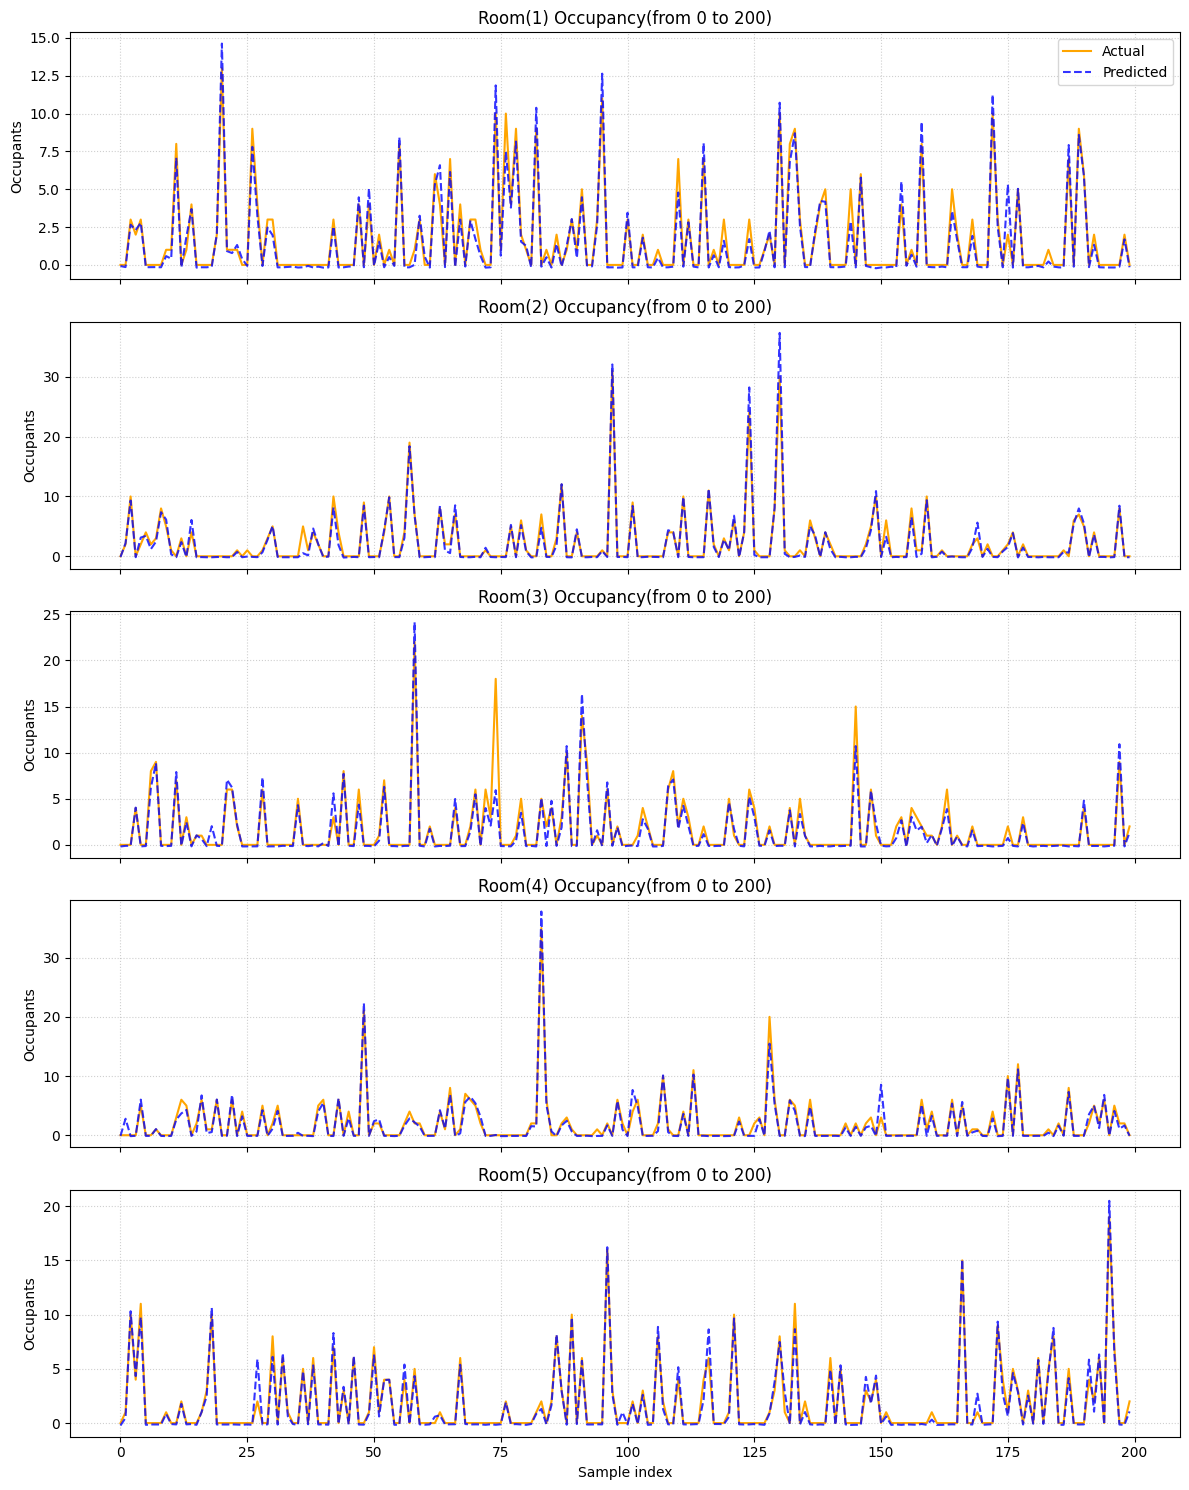

'\nprint("\n Final Evaluation Metrics Per Room (Spatial Model):")\nwith open(summary_txt, "a") as f:\n    f.write("\n SPATIAL (Multi-Room) Transformer Evaluation \n")\n\n    # Store all spatial results\n    spatial_results = []\n    #gets the predictedd room for all samples at once\n    y_room_pred_all = np.argmax(preds_room_np, axis=-1)+1 #shape: (samples, num_rooms)\n    # Iterate through each room to calculate both occupancy and room number metrics\n    for room_index in range(config["num_rooms"]):\n        room_id_display = room_index + 1 # For printing and appending\n\n        # Occupancy Metrics\n        y_occup_true = actuals_occup_np[:, room_index]\n        y_occup_pred = preds_occup_np[:, room_index]\n        rmse_O = np.sqrt(mean_squared_error(y_occup_true, y_occup_pred))\n        mae_O = mean_absolute_error(y_occup_true, y_occup_pred)\n        r2_O = r2_score(y_occup_true, y_occup_pred)\n\n        # Room Number Metrics\n        # Convert numpy array to torch tensor before pa

In [22]:

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
plot_start = 0
plot_end = 200

# === TRAIN THE MODEL ===
preds_occup_np,preds_room_np, actuals_occup_np,actuals_room_np = train_multiroom_model(
    model=multi_room_model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=final_epochs,
    lr=0.001,
    edge_index=edge_index,
    edge_attr=edge_attr_scaled,
    node_features=node_features_scaled
)

print("\n Final Evaluation Metrics Per Room (Spatial Model):")
with open(summary_txt, "a") as f:
    f.write("\n SPATIAL (Multi-Room) Transformer Evaluation \n")

    # Store all spatial results
    spatial_results = []
    #gets the predictedd room for all samples at once
    y_room_pred_all = np.argmax(preds_room_np,axis=-1).flatten()+1 #shape: (samples, num_rooms)
    y_room_true_all = (actuals_room_np).astype(int).flatten() # plus two to fix error with cm matrix not showing all collumns
    #print("Debug: pred ",y_room_pred_all)
    #print("Debug: true ",y_room_true_all)
    all_room_labels= list(range(1,config["num_rooms"]+1))
    cm = confusion_matrix(
        y_room_true_all,
        y_room_pred_all,
        labels=all_room_labels
    )
    print(cm)
    print(
        classification_report(
            y_room_true_all,
            y_room_pred_all,
            labels=all_room_labels,
            target_names=[str(x) for x in all_room_labels],
            zero_division = 0)
    )
  #  cm.print_stats()
    #Subplots for occupancy
    num_rooms=config["num_rooms"]
    fig, axes = plt.subplots(num_rooms, 1, figsize=(12,3*num_rooms),sharex=True)
    
            # Iterate through each room to calculate both occupancy and room number metrics
    for room_index in range(config["num_rooms"]):
            room_id_display = room_index + 1 # For printing and appending

            # Occupancy Metrics
            y_occup_true = actuals_occup_np[:, room_index]
            y_occup_pred = preds_occup_np[:, room_index]
            rmse_O = np.sqrt(mean_squared_error(y_occup_true, y_occup_pred))
            mae_O = mean_absolute_error(y_occup_true, y_occup_pred)
            r2_O = r2_score(y_occup_true, y_occup_pred)

            # Room Number Metrics
            # Convert numpy array to torch tensor before passing to torch.argmax


            #rmse_R = np.sqrt(mean_squared_error(y_room_true, y_room_pred_numpy))
            #mae_R = mean_absolute_error(y_room_true, y_room_pred_numpy)
            #r2_R = r2_score(y_room_true, y_room_pred_numpy)

            print(f"\nRoom {room_id_display}:")
            print(f"  RMSE_O: {rmse_O:.3f}")
            print(f"  MAE_O : {mae_O:.3f}")
            print(f"  R²_O  : {r2_O:.3f}")



        # Append all metrics for the current room as a single tuple
            spatial_results.append((room_id_display, rmse_O, mae_O, r2_O))

        #Slice the data for the plot
            true_slice = y_occup_true[plot_start:plot_end]
            pred_slice = y_occup_pred[plot_start:plot_end]
            x_axis = range(plot_start,plot_start+len(true_slice))

        #Generate Subplot for current room
            ax = axes[room_index]
            ax.plot(x_axis,true_slice,label="Actual", color="orange",linewidth=1.5)
            ax.plot(x_axis,pred_slice,label="Predicted", color="blue",linestyle="--",alpha=0.8)
            ax.set_title(f"Room({room_id_display}) Occupancy(from {plot_start} to {plot_end})")
            ax.set_ylabel("Occupants")
            ax.grid(True,linestyle=":",alpha=0.6)
            if room_index == 0:
                ax.legend(loc="upper right")

    axes[-1].set_xlabel("Sample index")
    plt.tight_layout()

    plt.show()
    f.write(f"Confusion Matrix: {cm}\n")
    # Write in temporal-style format
    # The loop will now correctly unpack 7 values from each tuple in spatial_results
    for room_id_from_tuple, rmse_O, mae_O, r2_O in spatial_results:
        f.write(f"R{room_id_from_tuple}\tRMSE_O: {rmse_O:.4f}\tRMSE_R: \tMAE_O: {mae_O:.4f}\tMAE_R: \tR²_O: {r2_O:.4f}\n")
'''
print("\n Final Evaluation Metrics Per Room (Spatial Model):")
with open(summary_txt, "a") as f:
    f.write("\n SPATIAL (Multi-Room) Transformer Evaluation \n")

    # Store all spatial results
    spatial_results = []
    #gets the predictedd room for all samples at once
    y_room_pred_all = np.argmax(preds_room_np, axis=-1)+1 #shape: (samples, num_rooms)
    # Iterate through each room to calculate both occupancy and room number metrics
    for room_index in range(config["num_rooms"]):
        room_id_display = room_index + 1 # For printing and appending

        # Occupancy Metrics
        y_occup_true = actuals_occup_np[:, room_index]
        y_occup_pred = preds_occup_np[:, room_index]
        rmse_O = np.sqrt(mean_squared_error(y_occup_true, y_occup_pred))
        mae_O = mean_absolute_error(y_occup_true, y_occup_pred)
        r2_O = r2_score(y_occup_true, y_occup_pred)

        # Room Number Metrics
        # Convert numpy array to torch tensor before passing to torch.argmax
        y_room_true = (actuals_room_np[:,room_index]).astype(int)

        y_room_pred_numpy = y_room_pred_all[:,room_index] # Convert back to numpy for sklearn metrics
        all_room_labels = list(range(1,config["num_rooms"]+1))

        cm = pd.crosstab(
                pd.Series(y_room_true, name='Actual'),
                pd.Series(y_room_pred_numpy, name ='Predicted'),
                rownames=['Actual'],
                colnames=['Predicted'],
                dropna=False

        )
        cm = cm.reindex(
                index=all_room_labels,
                columns=all_room_labels,
                fill_value=0
        )
        #rmse_R = np.sqrt(mean_squared_error(y_room_true, y_room_pred_numpy))
        #mae_R = mean_absolute_error(y_room_true, y_room_pred_numpy)
        #r2_R = r2_score(y_room_true, y_room_pred_numpy)

        print(f"\nRoom {room_id_display}:")
        print(f"  RMSE_O: {rmse_O:.3f}")
        print(f"  MAE_O : {mae_O:.3f}")
        print(f"  R²_O  : {r2_O:.3f}")

        print(f"\nRoom {room_index +1} Confusion Matrix:")
        print(cm)

        # Append all metrics for the current room as a single tuple
        spatial_results.append((room_id_display, rmse_O, mae_O, r2_O,cm))

    # Write in temporal-style format
    # The loop will now correctly unpack 7 values from each tuple in spatial_results
    for room_id_from_tuple, rmse_O, mae_O, r2_O, cm in spatial_results:
        f.write(f"R{room_id_from_tuple}\tRMSE_O: {rmse_O:.4f}\tRMSE_R: \tMAE_O: {mae_O:.4f}\tMAE_R: \tR²_O: {r2_O:.4f}\tCM: {cm}\n")
'''

In [ ]:


def plot_multiroom_loss_subplots(train_losses_per_room, test_losses_per_room, room_names, save_path):
    fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharey=True)
    axs = axs.flatten()
    fig.suptitle("Spatial Train/Test Loss per Room", fontsize=16)

    for i, room in enumerate(room_names):
        axs[i].plot(train_losses_per_room[room], label='Train Loss')
        axs[i].plot(test_losses_per_room[room], label='Test Loss')
        axs[i].set_title(room)
        axs[i].set_xlabel("Epoch")
        axs[i].grid(True)
        if i == 0:
            axs[i].set_ylabel("Loss")
        axs[i].legend()
    fig.delaxes(axs[-1])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path)
    plt.close()

In [ ]:


def plot_multiroom_accuracy_subplots(train_accs_per_room, test_accs_per_room, room_names, save_path):
    fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharey=True)
    axs = axs.flatten()
    fig.suptitle("Spatial Train/Test Accuracy per Room", fontsize=16)

    for i, room in enumerate(room_names):
        axs[i].plot(train_accs_per_room[room], label='Train Acc')
        axs[i].plot(test_accs_per_room[room], label='Test Acc')
        axs[i].set_title(room)
        axs[i].set_xlabel("Epoch")
        axs[i].grid(True)
        if i == 0:
            axs[i].set_ylabel("Accuracy")
        axs[i].legend()
    fig.delaxes(axs[-1])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path)
    plt.close()

In [ ]:


def plot_multiroom_actual_vs_predicted_subplots(preds_per_room, actuals_per_room, room_names, save_path):
    fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharey=True)
    axs = axs.flatten()
    fig.suptitle("Spatial Actual vs Predicted (First 100 Samples)", fontsize=16)

    for i, room in enumerate(room_names):
        axs[i].plot(actuals_per_room[room], label='Actual')
        axs[i].plot(preds_per_room[room], label='Predicted')
        axs[i].set_title(room)
        axs[i].set_xlabel("Index")
        axs[i].grid(True)
        if i == 0:
            axs[i].set_ylabel("Occupancy")
        axs[i].legend()
    fig.delaxes(axs[-1])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path)
    plt.close()

In [ ]:


# === CALL GROUPED PLOTS ===
plot_multiroom_loss_subplots(
    spatial_train_losses_per_room,
    spatial_test_losses_per_room,
    room_names,
    os.path.join(RESULTS_DIR, "multiroom_loss_all_rooms.png")
)

plot_multiroom_accuracy_subplots(
    spatial_train_accs_per_room,
    spatial_test_accs_per_room,
    room_names,
    os.path.join(RESULTS_DIR, "multiroom_accuracy_all_rooms.png")
)

In [ ]:


# Populate spatial_preds_per_room and spatial_actuals_per_room
# These were populated within train_multiroom_model but were not correctly assigned to the top-level variables expected by the plot function.
spatial_preds_per_room = spatial_occupancy_preds_per_room
spatial_actuals_per_room = spatial_occupancy_actuals_per_room

In [ ]:


plot_multiroom_actual_vs_predicted_subplots(
    spatial_preds_per_room,
    spatial_actuals_per_room,
    room_names,
    os.path.join(RESULTS_DIR, "multiroom_actual_vs_predicted_all_rooms.png")
)

In [ ]:


# === GET ONE BATCH FROM TEST LOADER ===
multiroom_batch = next(iter(test_loader))  # or use train_loader
X_batch = multiroom_batch[0].to(device)    # shape: (batch_size, num_rooms, seq_len, input_dim)

In [ ]:


# === Confirm input shape ===
print("X_batch shape:", X_batch.shape)  # Should be (batch, num_rooms, seq_len, input_dim)

In [ ]:


# === PLOT ROOM DEPENDENCY HEATMAP === change for room dependency bookmark7
def plot_room_dependency_heatmap(model, input_batch, room_names=None, save=True, show=False):
    model.eval()
    with torch.no_grad():
        assert input_batch.ndim == 4, f"Expected shape (batch, rooms, seq_len, features), got {input_batch.shape}"
        batch_size, num_rooms, seq_len, input_dim = input_batch.shape

        # Encode each room using its temporal encoder
        room_contexts = []
        for r in range(num_rooms):
            x_room = input_batch[:, r]  # (batch, seq_len, input_dim)
            encoded = model.room_encoders[r](x_room)  # (batch, seq_len, hidden_dim)
            pooled = encoded.mean(dim=1)  # (batch, hidden_dim)
            room_contexts.append(pooled)

        room_contexts = [model.temporal_to_spatial(c) for c in room_contexts]

        # Stack into (batch, num_rooms, hidden_dim)
        context_tensor = torch.stack(room_contexts, dim=1)

        # Apply spatial encoder to get fused representation
        fused = model.spatial_encoder(context_tensor)  # (batch, num_rooms, hidden_dim)

        # Average across the batch → (num_rooms, hidden_dim)
        avg_representation = fused.mean(dim=0).cpu().numpy()

        # Compute correlation matrix → (num_rooms, num_rooms)
        corr_matrix = np.corrcoef(avg_representation)

        # Plot heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
                    xticklabels=room_names, yticklabels=room_names)
        plt.title("Room Dependency Heatmap (Learned Spatial Representations)")
        plt.xlabel("Rooms")
        plt.ylabel("Rooms")

        if save:
            plt.savefig(os.path.join(RESULTS_DIR, "multiroom_room_dependency_heatmap.png"))
        if show:
            plt.show()
        else:
            plt.close()

In [ ]:


# === CALL FUNCTION ===
plot_room_dependency_heatmap(multi_room_model, X_batch, room_names)

In [ ]:


# === SAVE RUNTIME INFO ===
end_time = time.time()
elapsed_time = end_time - start_time
elapsed_minutes = elapsed_time / 60

with open(summary_txt, "a") as f:
    f.write(f"\nTotal Runtime: {elapsed_time:.2f} seconds ({elapsed_minutes:.2f} minutes)\n")